# S12 - Splitting the fleet between this model and the physical model

`HANDOFF_split_with_physical_model.md`, 2026-09-11. **Each household is scored by exactly one method on the dashboard.** Audited houses the physical model can assess go to it; everyone else stays here, on `meta_data`, exactly as before.

**The 118 leave the dashboard queue, not the model.** Every validation figure behind *"not shown to work, not shown to fail"* is computed on audited households, so the model keeps scoring them. A column is added; no row is deleted. No physical-model number enters this model's scoring.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
OUT = Path.cwd() if Path.cwd().name=="s12" else Path("outputs/s12")
DATA, FIG = OUT/"data", OUT/"figures"; FIG.mkdir(exist_ok=True,parents=True)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":120,"font.size":9,
 "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,
 "grid.alpha":.25,"grid.linewidth":.6,"figure.facecolor":"white","axes.facecolor":"white"})
CA,CB,CC="#B03030","#C1663B","#C8D2DA"
CPHYS,CSTRAT="#3B5B8C","#8A8F98"
d=pd.read_parquet(DATA/"s12_scored_fleet.parquet")
q=pd.read_parquet(DATA/"s12_dashboard_queue.parquet")
cnt=pd.read_csv(DATA/"s12_counts_by_baseline.csv",sep=";")
ov=pd.read_csv(DATA/"s12_physical_overlap.csv",sep=";")
print(f"model fleet {len(d)}  |  dashboard queue {len(q)}")

model fleet 1127  |  dashboard queue 1009


## 1. The split

scored_by,physical,stratum,All
audited,,,
audited,118,16,134
not audited,0,993,993
All,118,1009,1127


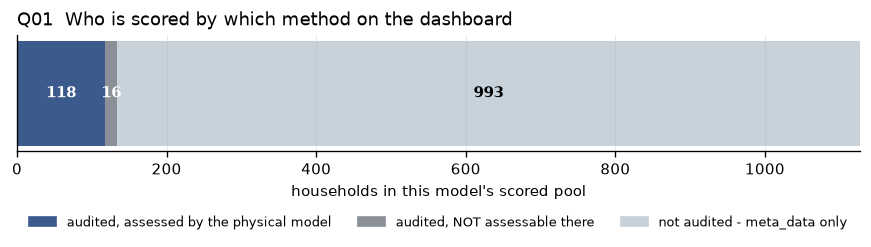

The key is 'assessed by the physical model', never 'has a protocol'.
Keyed on the protocol, the middle block would drop out of BOTH models.


In [2]:
t=pd.crosstab(d.audited.map({True:"audited",False:"not audited"}),d.scored_by,margins=True)
display(t)
fig,ax=plt.subplots(figsize=(8,2.6))
parts=[("audited, assessed by the physical model",int((d.scored_by=="physical").sum()),CPHYS),
       ("audited, NOT assessable there",int((d.audited&(d.scored_by=="stratum")).sum()),CSTRAT),
       ("not audited - meta_data only",int((~d.audited).sum()),CC)]
left=0
for lab,n,c in parts:
    ax.barh([0],[n],left=left,color=c,height=.5)
    ax.text(left+n/2,0,f"{n}",ha="center",va="center",fontsize=9,weight="bold",
            color="white" if c!=CC else "black")
    left+=n
ax.set_yticks([]); ax.set_xlim(0,len(d)); ax.set_xlabel("households in this model's scored pool")
ax.legend([plt.Rectangle((0,0),1,1,color=c) for _,_,c in parts],[p[0] for p in parts],
          fontsize=8,frameon=False,loc="upper center",bbox_to_anchor=(.5,-.45),ncol=3)
ax.set_title("Q01  Who is scored by which method on the dashboard",loc="left")
plt.tight_layout(); plt.savefig(FIG/"Q01_split.png",bbox_inches="tight"); plt.show()
print("The key is 'assessed by the physical model', never 'has a protocol'.")
print("Keyed on the protocol, the middle block would drop out of BOTH models.")

## 2. The queue after the split, per baseline

,baseline,category,before,after,leaving,matches_handoff
0,"non-PV, whole-house meter",A,58,50,8,True
1,"non-PV, whole-house meter",B,33,26,7,True
2,"non-PV, whole-house meter",C,589,519,70,True
3,"PV, whole-house meter (grid import)",A,36,32,4,True
4,"PV, whole-house meter (grid import)",B,27,27,0,True
5,"PV, whole-house meter (grid import)",C,316,295,21,True
6,"sub-metered, heat-pump meter",A,8,8,0,True
7,"sub-metered, heat-pump meter",B,8,7,1,True
8,"sub-metered, heat-pump meter",C,52,45,7,True


matches the handoff's section 3 in every cell: True


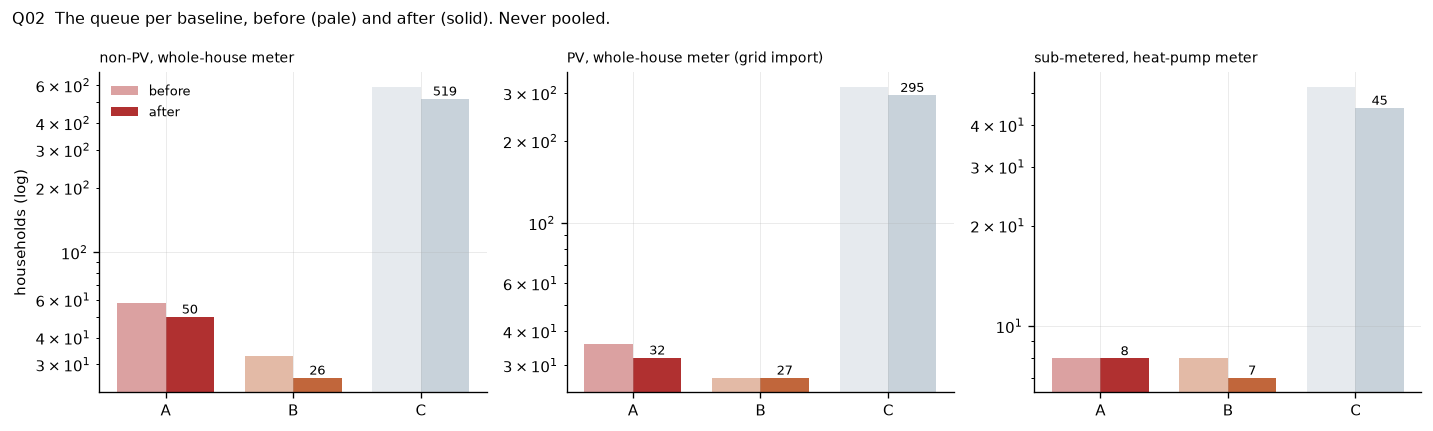

,before,after,leaving
category,,,
A,102,90,12
B,68,60,8
C,957,859,98


Each baseline keeps its own reference and its own within-group z.


In [3]:
display(cnt.drop(columns=["handoff_before","handoff_after"]))
print("matches the handoff's section 3 in every cell:",bool(cnt.matches_handoff.all()))
B=list(dict.fromkeys(cnt.baseline))
fig,axes=plt.subplots(1,3,figsize=(12,3.6))
for ax,b in zip(axes,B):
    s=cnt[cnt.baseline==b].set_index("category")
    x=np.arange(3); w=.38
    ax.bar(x-w/2,s.before,width=w,color=[CA,CB,CC],alpha=.45,label="before")
    ax.bar(x+w/2,s.after,width=w,color=[CA,CB,CC],label="after")
    for i,c in enumerate("ABC"):
        ax.text(i+w/2,s.loc[c,"after"],f"{s.loc[c,'after']}",ha="center",va="bottom",fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(list("ABC")); ax.set_yscale("log")
    ax.set_title(b,loc="left",fontsize=8.5)
axes[0].set_ylabel("households (log)"); axes[0].legend(fontsize=8,frameon=False)
fig.suptitle("Q02  The queue per baseline, before (pale) and after (solid). Never pooled.",
             x=.01,ha="left",fontsize=9.5)
plt.tight_layout(); plt.savefig(FIG/"Q02_queue_by_baseline.png"); plt.show()
tot=cnt.groupby("category")[["before","after","leaving"]].sum()
display(tot)
print("Each baseline keeps its own reference and its own within-group z.")

## 3. The 118 disagree with this model - expected, not a bug

phys_status,HIGH_EXCESS,EXCESS_CONFIRMED,INCONCLUSIVE,total
stratum_category,,,,
A,8,4,0,12
B,1,5,2,8
C,16,69,13,98


C:\Users\migue\AppData\Local\Temp\ipykernel_26384\2144859062.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(["A  fault candidate","B  high, no fault named","C  nothing material"][:len(x)])


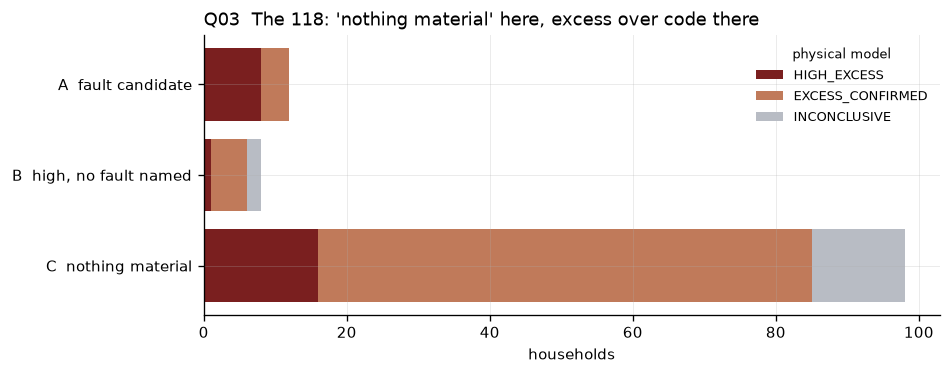

98 of 118 sit in this model's C; the physical model confirms an excess in 103 of 118.
This model: above COMPARABLE houses? The physical model: above a CODE-COMPLIANT
version of itself? An old leaky house among old leaky peers is ordinary here and
far above code there. Different questions - do not reconcile them.


In [4]:
x=pd.crosstab(ov.stratum_category,ov.phys_status)
x=x[[c for c in ["HIGH_EXCESS","EXCESS_CONFIRMED","INCONCLUSIVE"] if c in x.columns]]
display(x.assign(total=x.sum(axis=1)))
fig,ax=plt.subplots(figsize=(8,3.2))
cols={"HIGH_EXCESS":"#7A1F1F","EXCESS_CONFIRMED":"#C07A5A","INCONCLUSIVE":"#B8BCC4"}
left=np.zeros(len(x))
for c in x.columns:
    ax.barh(x.index,x[c],left=left,color=cols[c],label=c); left+=x[c].values
ax.invert_yaxis(); ax.set_xlabel("households")
ax.set_yticklabels(["A  fault candidate","B  high, no fault named","C  nothing material"][:len(x)])
ax.legend(fontsize=8,frameon=False,title="physical model",title_fontsize=8)
ax.set_title("Q03  The 118: 'nothing material' here, excess over code there",loc="left")
plt.tight_layout(); plt.savefig(FIG/"Q03_the_118.png"); plt.show()
exc=ov.phys_status.isin(["HIGH_EXCESS","EXCESS_CONFIRMED"])
print(f"{int((ov.stratum_category=='C').sum())} of {len(ov)} sit in this model's C; the physical "
      f"model confirms an excess in {int(exc.sum())} of {len(ov)}.")
print("This model: above COMPARABLE houses? The physical model: above a CODE-COMPLIANT")
print("version of itself? An old leaky house among old leaky peers is ordinary here and")
print("far above code there. Different questions - do not reconcile them.")

## 4. The dashboard queue - top of A and B

In [5]:
cols=["rank_in_category","Household_ID","baseline","cell","recoverable_kwh_yr","driver",
      "z_slope","z_floor","z_tau","candidate_setting"]
for c in ["A_configuration_fault_candidate","B_high_consumption_no_fault_identified"]:
    print(c); display(q[q.category==c][cols].head(10).round(2))
print("Ranked on ENERGY (kWh is comparable across baselines; z is not and travels as confidence).")
print("B is 'do not dispatch blind'. candidate_setting is a heuristic placeholder, not a detector.")

A_configuration_fault_candidate


,rank_in_category,Household_ID,baseline,cell,recoverable_kwh_yr,driver,z_slope,z_floor,z_tau,candidate_setting
0,1,120116,"non-PV, whole-house meter",AS_T2_mid,25659.24,baseload / hot water,4.32,8.63,NaN,heating curve too high
1,2,978870,"non-PV, whole-house meter",GS_T3_large,25393.38,baseload / hot water,4.68,3.34,1.35,heating curve too high
2,3,1186910,"sub-metered, heat-pump meter",AS,20324.86,baseload / hot water,3.29,3.01,0.34,heating curve too high
3,4,105697,"non-PV, whole-house meter",AS_T3_large,20290.03,baseload / hot water,2.63,6.02,1.62,heating curve too high
4,5,7873107,"non-PV, whole-house meter",AS_T1_small,13590.28,baseload / hot water,2.69,4.63,NaN,heating curve too high
5,6,410083,"PV, whole-house meter (grid import)",PV_AS_T3_large,12875.11,baseload / hot water,3.62,4.21,2.87,heating curve too high; heating limit too high
6,7,7870998,"non-PV, whole-house meter",AS_T2_mid,12671.72,heating settings,5.03,2.60,1.05,heating curve too high
7,8,468711,"PV, whole-house meter (grid import)",PV_GS_T3_large,12615.72,baseload / hot water,4.04,1.83,NaN,heating curve too high
8,9,382698,"PV, whole-house meter (grid import)",PV_GS_T3_large,11132.32,baseload / hot water,2.61,1.16,NaN,heating curve too high
9,10,1011223,"non-PV, whole-house meter",AS_T1_small,10926.11,baseload / hot water,2.33,4.88,-0.84,heating curve too high


B_high_consumption_no_fault_identified


,rank_in_category,Household_ID,baseline,cell,recoverable_kwh_yr,driver,z_slope,z_floor,z_tau,candidate_setting
90,1,8701118,"non-PV, whole-house meter",GS_T3_large,25061.14,baseload / hot water,-0.59,6.56,NaN,
91,2,6810697,"PV, whole-house meter (grid import)",PV_AS_T3_large,19091.88,baseload / hot water,-1.12,6.84,NaN,
92,3,108787,"PV, whole-house meter (grid import)",PV_AS_T2_mid,18275.57,baseload / hot water,1.49,7.08,NaN,
93,4,1118887,"PV, whole-house meter (grid import)",PV_GS_T3_large,16434.27,baseload / hot water,0.79,3.69,NaN,
94,5,4657676,"non-PV, whole-house meter",GS_T3_large,14324.02,baseload / hot water,-0.68,2.47,NaN,
95,6,8211908,"non-PV, whole-house meter",GS_T3_large,13697.51,baseload / hot water,0.43,2.87,NaN,
96,7,7699120,"PV, whole-house meter (grid import)",PV_GS_T3_large,12720.97,baseload / hot water,-0.41,4.09,NaN,
97,8,376757,"non-PV, whole-house meter",AS_T2_mid,12021.99,baseload / hot water,-0.67,5.23,NaN,
98,9,2701087,"non-PV, whole-house meter",AS_T3_large,10308.10,baseload / hot water,0.17,3.67,NaN,
99,10,100778,"non-PV, whole-house meter",AS_T3_large,9801.22,baseload / hot water,-1.02,4.62,-0.67,


Ranked on ENERGY (kWh is comparable across baselines; z is not and travels as confidence).
B is 'do not dispatch blind'. candidate_setting is a heuristic placeholder, not a detector.


## Verdict

**1,127 → 1,009 on the dashboard queue**, `scored_by` physical 118 / stratum 1,009. Per baseline A 102 → 90, B 68 → 60, C 957 → 859 - every cell matches the handoff, and the scoring columns are identical to S9 on all 1,127 rows.

**The 16 audited-but-not-assessable houses stay here.** Keyed on "has a protocol" they would have vanished from both models.

**98 of the 118 are 'nothing material' here while the physical model confirms an excess in 103.** The two models answer different questions, which is exactly why each house is scored by one of them and they are never combined into one number.

**Open, Miguel's call:** the 15 `INCONCLUSIVE` houses go to the physical model under the rule and show "no finding" there. Routing them back here would change the key to `phys_status in {HIGH_EXCESS, EXCESS_CONFIRMED}` and move the counts.